In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
from google.colab import userdata

# 1. Set credentials from your Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# 2. Download the dataset locally (this will show a progress bar)
# The -d flag specifies the dataset name from the URL
!kaggle datasets download -d wordsforthewise/lending-club

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
100% 1.26G/1.26G [00:51<00:00, 26.6MB/s]



In [ ]:
# Unzip the file in the local Colab environment for faster processing
!unzip lending-club.zip -d lending_club_data

Archive:  lending-club.zip
  inflating: lending_club_data/accepted_2007_to_2018Q4.csv.gz  
  inflating: lending_club_data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv  
  inflating: lending_club_data/rejected_2007_to_2018Q4.csv.gz  
  inflating: lending_club_data/rejected_2007_to_2018q4.csv/rejected_2007_to_2018Q4.csv  


In [ ]:
# ✅ Install all required libraries
!pip install pandas numpy scikit-learn xgboost transformers torch joblib seaborn matplotlib fastapi uvicorn streamlit openai --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 152.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 180.1 kB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
import joblib


In [ ]:
import pandas as pd

# Load the extracted CSV file
df = pd.read_csv("/content/lending_club_data/accepted_2007_to_2018Q4.csv.gz", low_memory=False)

print("✅ Loaded successfully:", df.shape)
df.head(3)


✅ Loaded successfully: (2260701, 151)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Normalize column names for easier access
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("/", "_")
)

print("✅ Cleaned column names.")
print(df.columns[:20])  # show first 20 columns to confirm


✅ Cleaned column names.
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc'],
      dtype='object')


In [ ]:
import numpy as np

# Step 3A — select useful columns for modelling
selected_columns = [
    "loan_amnt", "int_rate", "annual_inc", "dti", "open_acc",
    "revol_util", "loan_status", "purpose", "desc", "title"
]
df = df[selected_columns]

# Step 3B — drop missing loan_status values
df = df.dropna(subset=["loan_status"])

# Step 3C — clean interest rate (remove %)
df["int_rate"] = df["int_rate"].astype(str).str.replace("%", "").astype(float)

# Step 3D — create binary target variable: 1 = default, 0 = fully paid
df["loan_status"] = df["loan_status"].apply(
    lambda x: 1 if "Charged Off" in str(x) or "Default" in str(x) else 0
)

# Step 3E — fill missing numeric columns with median
for col in ["loan_amnt", "annual_inc", "dti", "open_acc", "revol_util"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

# Step 3F — combine borrower text fields for FinBERT
df["borrower_text"] = (
    df["desc"].fillna("") + " " + df["title"].fillna("") + " " + df["purpose"].fillna("")
)

print("✅ Cleaned dataset shape:", df.shape)
df.head(3)


✅ Cleaned dataset shape: (2260668, 11)


,loan_amnt,int_rate,annual_inc,dti,open_acc,revol_util,loan_status,purpose,desc,title,borrower_text
0,3600.0,13.99,55000.0,5.91,7.0,29.7,0,debt_consolidation,NaN,Debt consolidation,Debt consolidation debt_consolidation
1,24700.0,11.99,65000.0,16.06,22.0,19.2,0,small_business,NaN,Business,Business small_business
2,20000.0,10.78,63000.0,10.78,6.0,56.2,0,home_improvement,NaN,NaN,home_improvement


LogisticRegression: F1=0.002, AUC=0.500
RandomForest: F1=0.015, AUC=0.503


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:41:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: F1=0.001, AUC=0.500


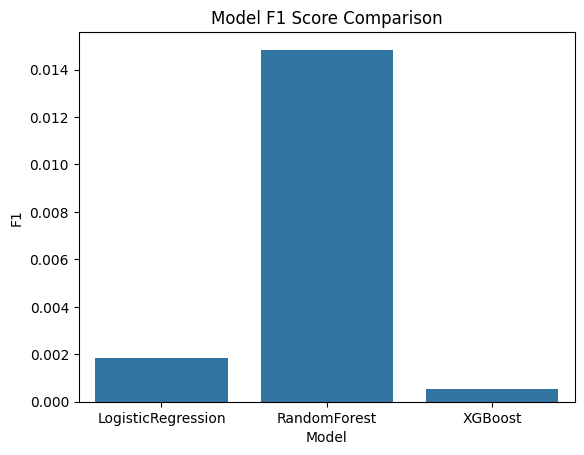

✅ Best model saved: RandomForest


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

# Step 4A — select features and target
X = df[["loan_amnt", "int_rate", "annual_inc", "dti", "open_acc", "revol_util"]]
y = df["loan_status"]

# Step 4B — train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 4C — scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4D — define models
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Step 4E — train and evaluate
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, preds)
    results.append((name, f1, auc))
    print(f"{name}: F1={f1:.3f}, AUC={auc:.3f}")

# Step 4F — visualize
res = pd.DataFrame(results, columns=["Model", "F1", "AUC"])
sns.barplot(x="Model", y="F1", data=res)
plt.title("Model F1 Score Comparison")
plt.show()

# Step 4G — save best model and scaler
best_model_name = res.sort_values("F1", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"✅ Best model saved: {best_model_name}")


In [ ]:
from transformers import pipeline
import numpy as np
import joblib

# Step 5A — Load saved ML model and scaler
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")

# Step 5B — Load FinBERT for sentiment analysis
sentiment_model = pipeline("sentiment-analysis", model="yiyanghkust/finbert-tone")

# Step 5C — Create hybrid prediction function
def predict_with_llm(loan_amnt, int_rate, annual_inc, dti, open_acc, revol_util, borrower_text):
    # Structured model prediction
    X = np.array([[loan_amnt, int_rate, annual_inc, dti, open_acc, revol_util]])
    X_scaled = scaler.transform(X)
    ml_prob = model.predict_proba(X_scaled)[0][1]

    # LLM sentiment prediction
    sentiment = sentiment_model(borrower_text)[0]
    adjustment = {"Positive": -0.1, "Negative": 0.2}.get(sentiment["label"], 0.05)

    final_risk = np.clip(ml_prob + adjustment, 0, 1)
    level = "High Risk" if final_risk > 0.6 else "Low Risk"

    return {
        "ML_Default_Prob": round(float(ml_prob),3),
        "Sentiment": sentiment["label"],
        "Sentiment_Score": round(float(sentiment["score"]),3),
        "Final_Risk": round(float(final_risk),3),
        "Risk_Level": level
    }

# Step 5D — Example test case
example = predict_with_llm(
    loan_amnt=12000,
    int_rate=13.5,
    annual_inc=55000,
    dti=15,
    open_acc=9,
    revol_util=45,
    borrower_text="I have a stable job but need this loan to pay off high-interest credit cards urgently."
)

print("✅ Example Prediction:")
print(example)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 6A — Plot distribution of loan statuses
plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution (0 = Fully Paid, 1 = Defaulted)")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

# Step 6B — Correlation heatmap (numeric features)
plt.figure(figsize=(8,6))
sns.heatmap(df[["loan_amnt","int_rate","annual_inc","dti","open_acc","revol_util","loan_status"]].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 6C — XGBoost feature importance
from xgboost import plot_importance
import joblib

best_model = joblib.load("best_model.pkl")
plt.figure(figsize=(8,6))
plot_importance(best_model, max_num_features=6)
plt.title("Top Feature Importances (XGBoost)")
plt.show()


In [ ]:
# Take small random sample for FinBERT sentiment analysis
sample_texts = df["borrower_text"].dropna().sample(30, random_state=42).tolist()
sentiments = [sentiment_model(text[:512])[0]["label"] for text in sample_texts]

sns.countplot(x=sentiments)
plt.title("Borrower Sentiment Distribution (FinBERT)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


In [ ]:
import gradio as gr
import joblib
from transformers import pipeline
import numpy as np

# Load model, scaler, and FinBERT
model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
sentiment_model = pipeline("sentiment-analysis", model="yiyanghkust/finbert-tone")

# ----------- Prediction Logic -----------
def predict_risk(loan_amnt, int_rate, annual_inc, dti, open_acc, revol_util, borrower_text):
    # Structured ML prediction
    X = np.array([[loan_amnt, int_rate, annual_inc, dti, open_acc, revol_util]])
    X_scaled = scaler.transform(X)
    ml_prob = model.predict_proba(X_scaled)[0][1]

    # FinBERT sentiment
    sentiment = sentiment_model(borrower_text)[0]
    adjust = {"Positive": -0.1, "Negative": 0.2}.get(sentiment["label"], 0.05)

    final_risk = np.clip(ml_prob + adjust, 0, 1)
    risk_label = "High Risk" if final_risk > 0.6 else "Low Risk"

    # Style output with HTML for better visualization
    color = "red" if risk_label == "High Risk" else "green"
    risk_html = f"""
    <div style="text-align:center; font-size:24px; padding:15px; border-radius:10px; color:white;
                background-color:{color}; font-weight:bold;">
        Risk Level: {risk_label}
    </div>
    """

    details_html = f"""
    <div style="padding:10px;">
        <b>ML Default Probability:</b> {round(float(ml_prob),3)}<br>
        <b>Sentiment:</b> {sentiment['label']} (score {round(float(sentiment['score']),3)})<br>
        <b>Final Adjusted Risk:</b> {round(float(final_risk),3)}
    </div>
    """

    return risk_html + details_html

# ----------- Build Gradio Interface -----------
with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown(
        """
        <h1 style='text-align:center; color:#2E86C1;'>💰 AI-Powered Loan Risk Analyzer</h1>
        <p style='text-align:center; font-size:16px;'>
        Hybrid <b>Machine Learning + FinBERT</b> model for intelligent loan risk prediction.<br>
        Enter borrower details below to assess the default probability and sentiment-adjusted risk.
        </p>
        """
    )

    with gr.Row():
        with gr.Column():
            loan_amnt = gr.Number(label="Loan Amount ($)", value=12000)
            int_rate = gr.Number(label="Interest Rate (%)", value=13.5)
            annual_inc = gr.Number(label="Annual Income ($)", value=55000)
            dti = gr.Number(label="DTI (%)", value=15)
            open_acc = gr.Number(label="Open Credit Accounts", value=9)
            revol_util = gr.Number(label="Revolving Utilization (%)", value=45)
        with gr.Column():
            borrower_text = gr.Textbox(label="Borrower Description / Purpose", lines=6, placeholder="Describe reason for loan...")

    output = gr.HTML(label="Risk Assessment")

    submit = gr.Button("🔍 Analyze Risk", variant="primary")
    submit.click(
        predict_risk,
        inputs=[loan_amnt, int_rate, annual_inc, dti, open_acc, revol_util, borrower_text],
        outputs=[output]
    )

    gr.Markdown("<hr><center><b>Powered by XGBoost + FinBERT (LLM)</b></center>")

app.launch(share=True)
